# Digits Classification with Bernoulli Naive Bayes

In this notebook, we build a **Bernoulli Naive Bayes** classifier to recognize handwritten digits (0–9), using the built-in `load_digits` dataset from scikit-learn — the same dataset used in the MultinomialNB notebook.

## Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

## Load Dataset

In [29]:
df = load_digits()

In [30]:
X=df.data

In [31]:
y=df.target

## Train/Test Split

In [32]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.20 ,random_state=42
)

## Model Training

In [33]:
BernoulliNBModel = BernoulliNB(binarize=8.0)

In [34]:
BernoulliNBModel.fit(X_train,y_train)

BernoulliNB(binarize=8.0)

In [35]:
y_train_pred = BernoulliNBModel.predict(X_train)
y_test_pred = BernoulliNBModel.predict(X_test)

## Evaluate

In [36]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'{train_accuracy:.2f} , {test_accuracy:.2f}')

0.90 , 0.89


In [37]:
print(classification_report(y_train, y_train_pred), '\n', classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       145
           1       0.83      0.81      0.82       154
           2       0.91      0.88      0.89       144
           3       0.93      0.85      0.88       149
           4       0.97      0.91      0.94       135
           5       0.92      0.90      0.91       135
           6       0.95      0.95      0.95       146
           7       0.88      0.99      0.93       145
           8       0.83      0.84      0.84       144
           9       0.80      0.90      0.85       140

    accuracy                           0.90      1437
   macro avg       0.90      0.90      0.90      1437
weighted avg       0.90      0.90      0.90      1437
 
               precision    recall  f1-score   support

           0       0.97      0.94      0.95        33
           1       0.77      0.71      0.74        28
           2       0.88      0.85      0.86        33
           3       0.9

In [38]:
train_accuracy = BernoulliNBModel.score(X_train, y_train)
test_accuracy = BernoulliNBModel.score(X_test, y_test)

train_accuracy, test_accuracy

(0.8977035490605428, 0.8861111111111111)

## Confusion Matrix

Text(50.722222222222214, 0.5, 'Actual')

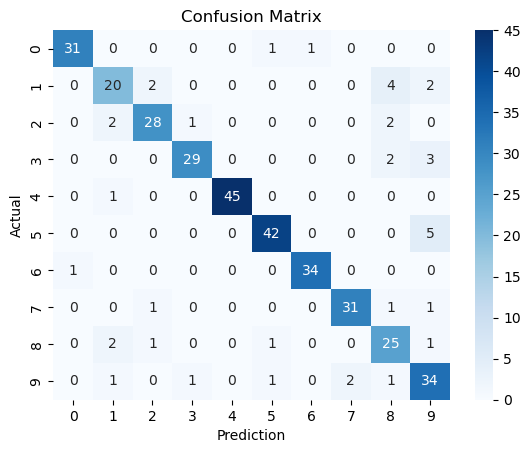

In [39]:
CM = confusion_matrix(y_test, y_test_pred)
sns.heatmap(
    CM,
    annot=True,
    cmap='Blues',
    xticklabels=df.target_names, yticklabels=df.target_names
)
plt.title('Confusion Matrix')
plt.xlabel('Prediction')
plt.ylabel('Actual')

## Conclusion

The Bernoulli Naive Bayes model achieves **90% accuracy on train** and **89% on test**, using only binary (on/off) pixel information — slightly lower than MultinomialNB's 91% on the same dataset, which makes sense since BernoulliNB throws away the intensity information (how bright a pixel is) and only keeps whether it's lit or not.

Digits **1**, **8**, and **9** again show the lowest precision/recall, consistent with the MultinomialNB results — these digits are visually similar and lose the most distinguishing information when reduced to binary pixels.